<a href="https://colab.research.google.com/github/007-athul/DSA-case-study1/blob/main/Case_study_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


Task 1: Data Preprocessing

In [90]:
df=pd.read_csv('adult_dataset.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [92]:
df.describe(),df.shape

(                age        fnlwgt  education-num  capital-gain  capital-loss  \
 count  46400.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
 mean      38.679116  1.896641e+05      10.078089   1079.067626     87.502314   
 std       13.952954  1.056040e+05       2.570973   7452.019058    403.004552   
 min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
 25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
 50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
 75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
 max      255.000000  1.490400e+06      16.000000  99999.000000   4356.000000   
 
        hours-per-week  
 count    46400.000000  
 mean        40.448599  
 std         12.646992  
 min          1.000000  
 25%         40.000000  
 50%         40.000000  
 75%         45.000000  
 max        250.000000  ,
 (48842, 15))

In [93]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [94]:
(df == "?").sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [95]:
df.replace('?',np.nan,inplace=True)

In [96]:
(df == "?").sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [97]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1155/91793064.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1155/91793064.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [98]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [99]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [100]:

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

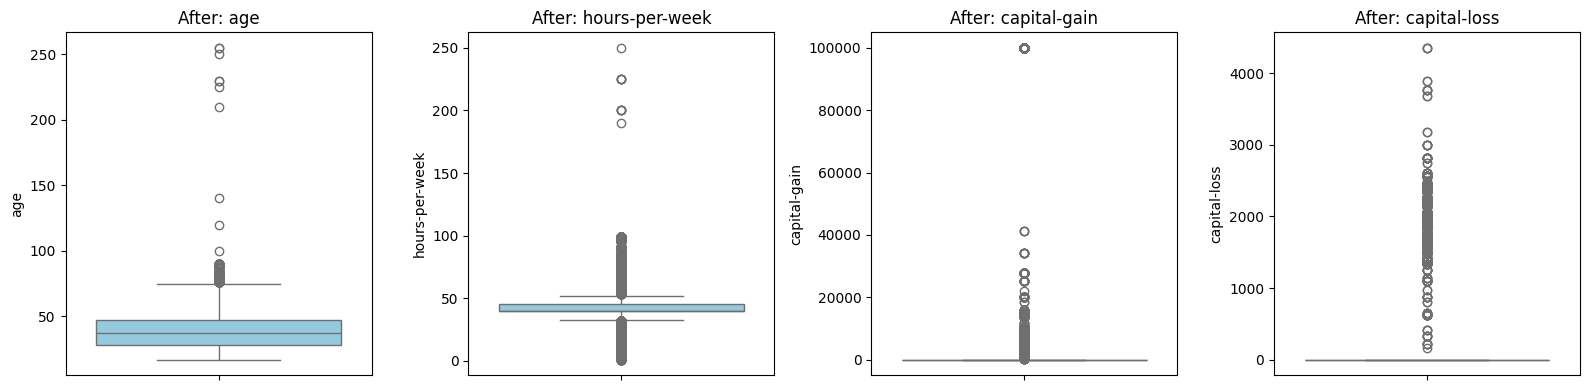

In [101]:
#outlier visualizing
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']
plt.figure(figsize=(16, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"After: {col}")
plt.tight_layout()
plt.show()

In [102]:
df = df[(df['age'] >= 17) & (df['age'] <= 100)]
df = df[df['hours-per-week'] <= 100]


In [103]:
#applied iqr
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    if IQR == 0:
        upper_bound = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper_bound)


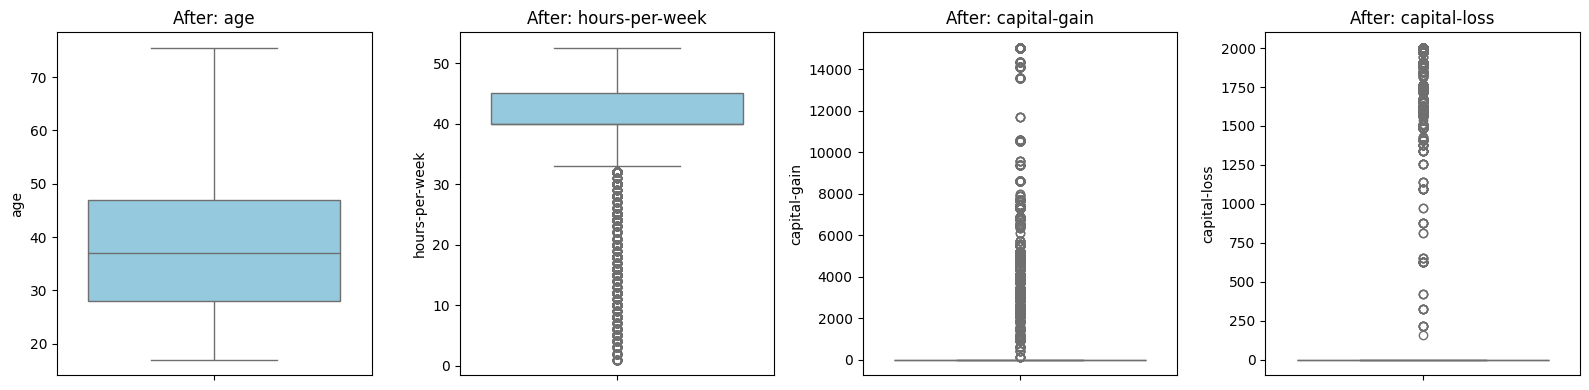

In [104]:
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']
plt.figure(figsize=(16, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"After: {col}")

plt.tight_layout()
plt.show()

In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
clean_df = df.drop(columns=['income', 'fnlwgt', 'education', 'native-country'], errors='ignore').copy()
for col in ['capital-gain', 'capital-loss']:
    clean_df[col] = np.log1p(clean_df[col])

num_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

X_scaled = preprocessor.fit_transform(clean_df)
X_scaled.shape

(48810, 41)

In [106]:
feature_names = preprocessor.get_feature_names_out()
scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
scaled_df.head()

,num__age,num__education-num,num__hours-per-week,num__capital-gain,num__capital-loss,cat__workclass_Local-gov,cat__workclass_Never-worked,cat__workclass_Private,cat__workclass_Self-emp-inc,cat__workclass_Self-emp-not-inc,...,cat__relationship_Not-in-family,cat__relationship_Other-relative,cat__relationship_Own-child,cat__relationship_Unmarried,cat__relationship_Wife,cat__race_Asian-Pac-Islander,cat__race_Black,cat__race_Other,cat__race_White,cat__sex_Male
0,0.035682,1.136585,0.073285,2.899950,-0.221317,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.865163,1.136585,-2.687779,-0.298927,-0.221317,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.039725,-0.419662,0.073285,-0.298927,-0.221317,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,1.091384,-1.197785,0.073285,-0.298927,-0.221317,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.793798,1.136585,0.073285,-0.298927,-0.221317,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


Task 2: Exploratory Analysis

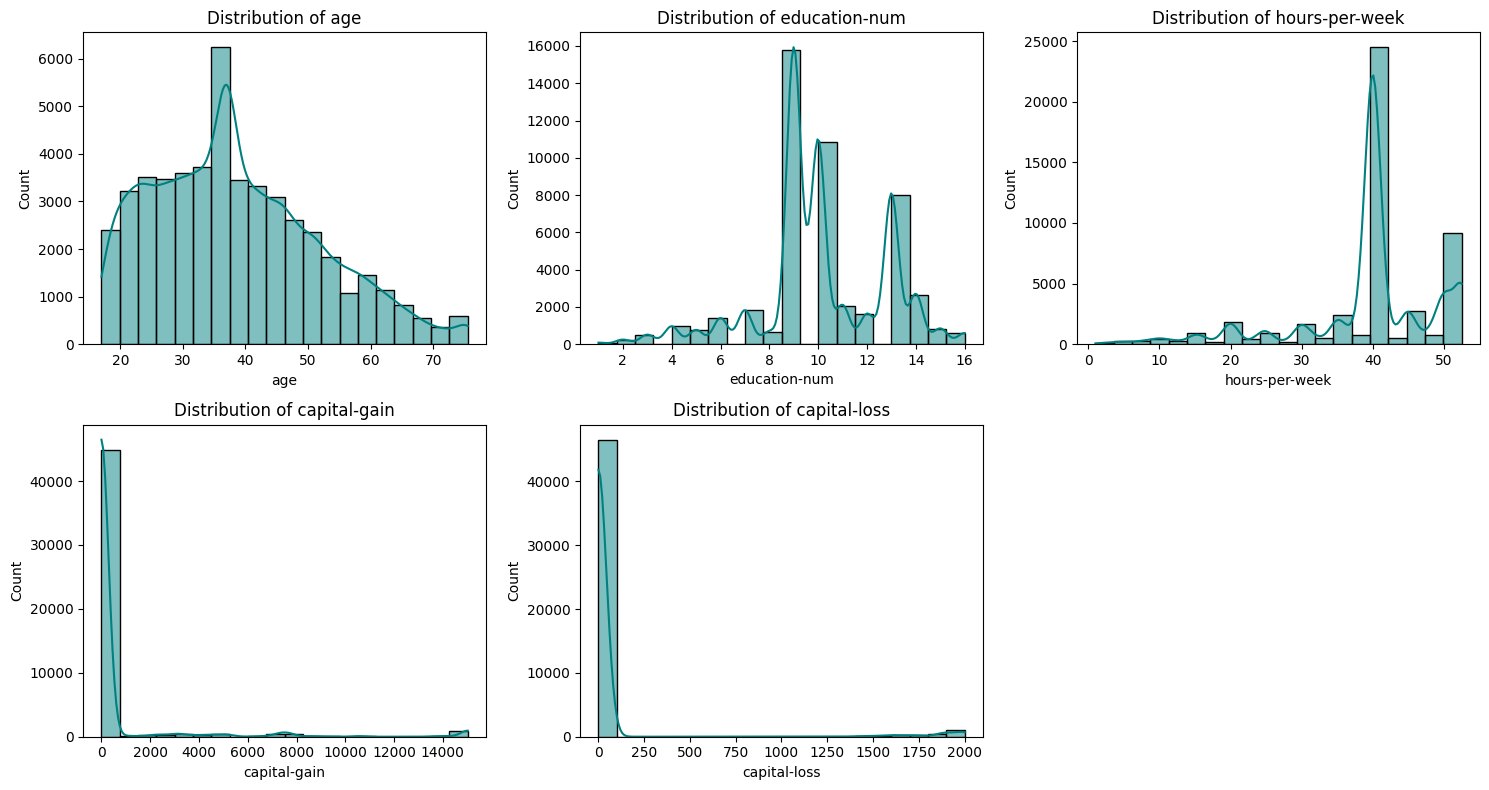

/tmp/ipykernel_1155/791335101.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_1155/791335101.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_1155/791335101.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_1155/791335101.py:19: FutureWarning: 

Passing `palette` without

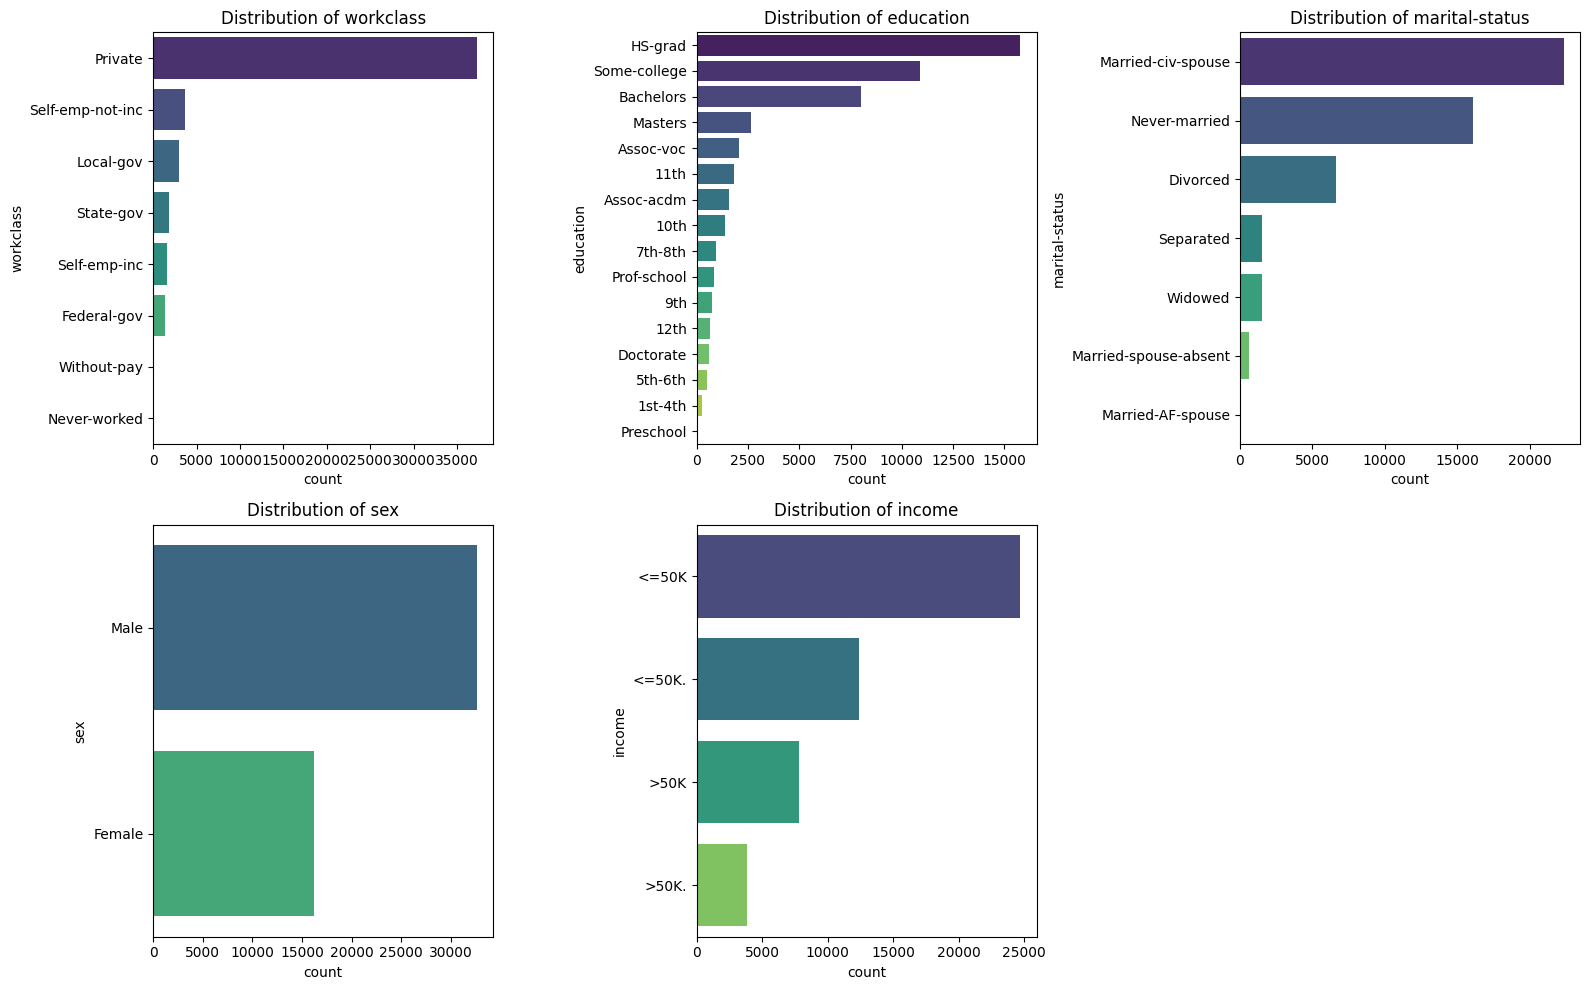

In [107]:
#Visualize Feature Distributions

num_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='teal', bins=20)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

cat_cols = ['workclass', 'education', 'marital-status', 'sex', 'income']

plt.figure(figsize=(16, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

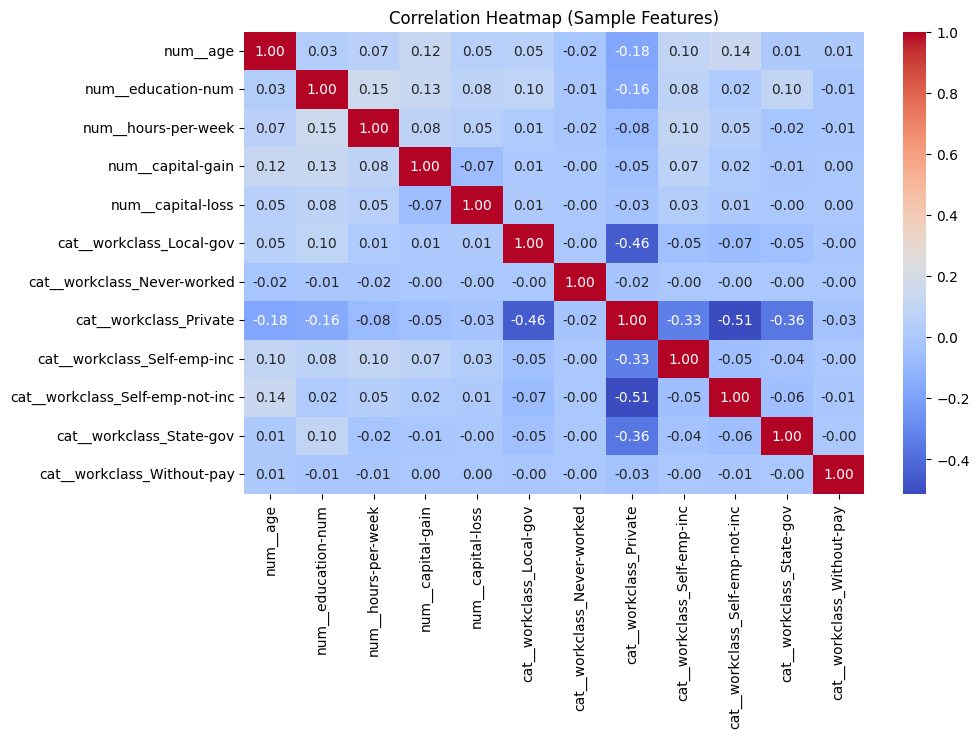

Explained Variance Ratio by top 2 components: 32.88%


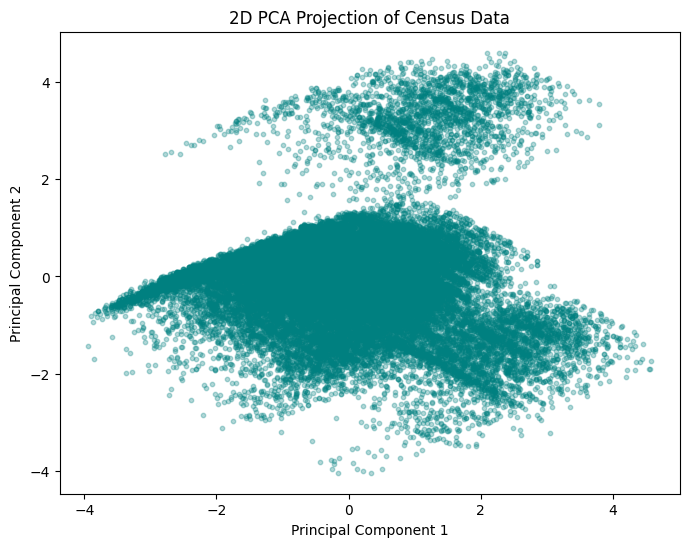

In [108]:
plt.figure(figsize=(10, 6))
sns.heatmap(scaled_df.iloc[:, :12].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Sample Features)")
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance Ratio by top 2 components: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, c='teal', s=10)
plt.title("2D PCA Projection of Census Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Task 3: Clustering

In [109]:
#clusters to test
k_range = range(2, 8)
inertia = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, cluster_labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)


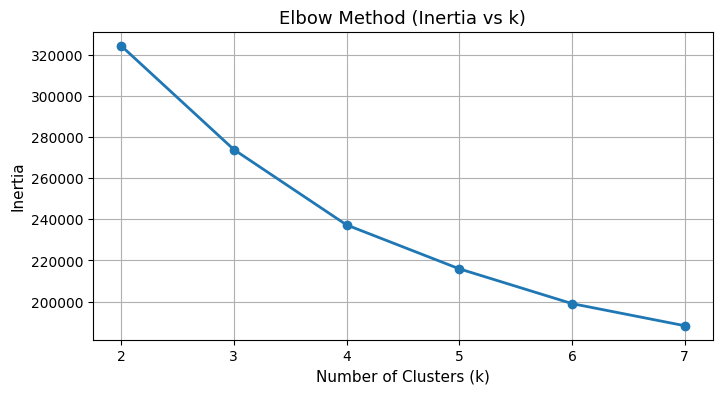

In [110]:
#elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'o-', color='tab:blue', linewidth=2)
plt.title('Elbow Method (Inertia vs k)', fontsize=13)
plt.xlabel('Number of Clusters (k)', fontsize=11)
plt.ylabel('Inertia', fontsize=11)
plt.grid(True)
plt.show()

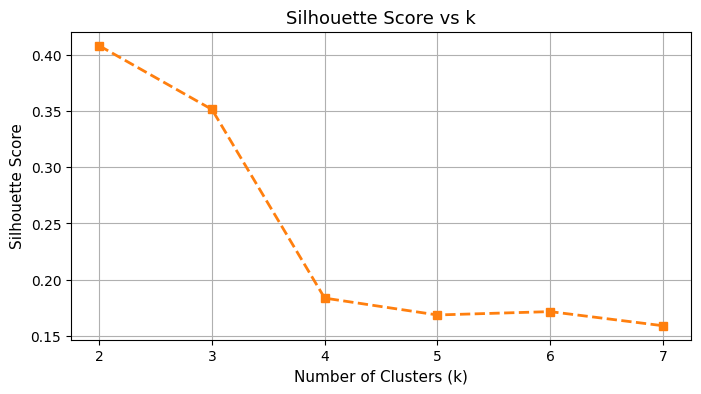

In [111]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, 's--', color='tab:orange', linewidth=2)
plt.title('Silhouette Score vs k', fontsize=13)
plt.xlabel('Number of Clusters (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.grid(True)
plt.show()

In [112]:
#kmeans silhouette score
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans_3.fit_predict(X_scaled[:5000])
km_silhouette = silhouette_score(X_scaled[:5000], km_labels)
km_silhouette

np.float64(0.35156648630831394)

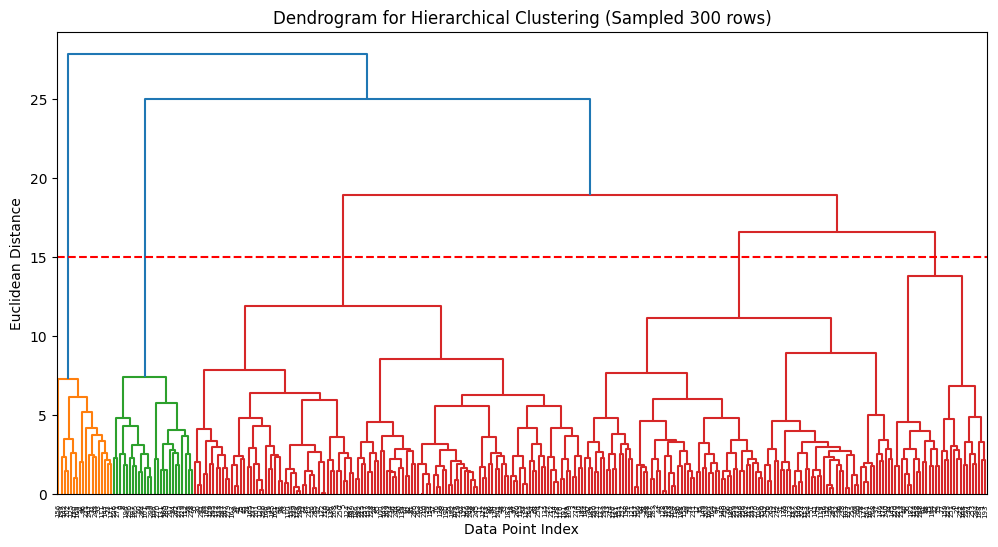

In [113]:
#agglo clustering
X_sample_dendro = X_scaled[:300]

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_sample_dendro, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering (Sampled 300 rows)')
plt.xlabel('Data Point Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

In [114]:

X_sample_agg = X_scaled[:5000]
agg_clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
agg_labels = agg_clustering.fit_predict(X_sample_agg)
agg_silhouette = silhouette_score(X_sample_agg, agg_labels)
print(f"Agglo Clustering Silhouette Score (k=3): {agg_silhouette:.4f}")

Agglo Clustering Silhouette Score (k=3): 0.3513


In [115]:

print("Model Comparison when (k=3)")
print(f"K-Means Silhouette Score:       {km_silhouette:.4f}")
print(f"Agglomerative Silhouette Score: {agg_silhouette:.4f}")

Model Comparison when (k=3)
K-Means Silhouette Score:       0.3516
Agglomerative Silhouette Score: 0.3513


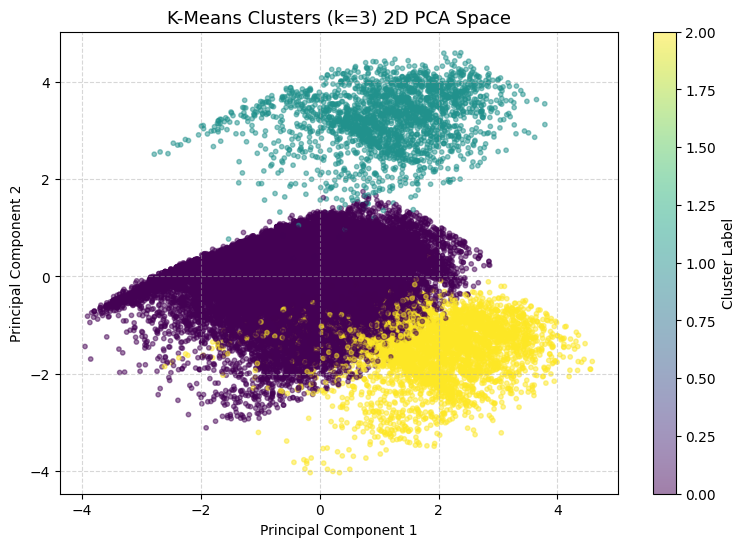

In [116]:
#inorder to visualize the clusters kmeans
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster Label')
plt.title('K-Means Clusters (k=3) 2D PCA Space', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


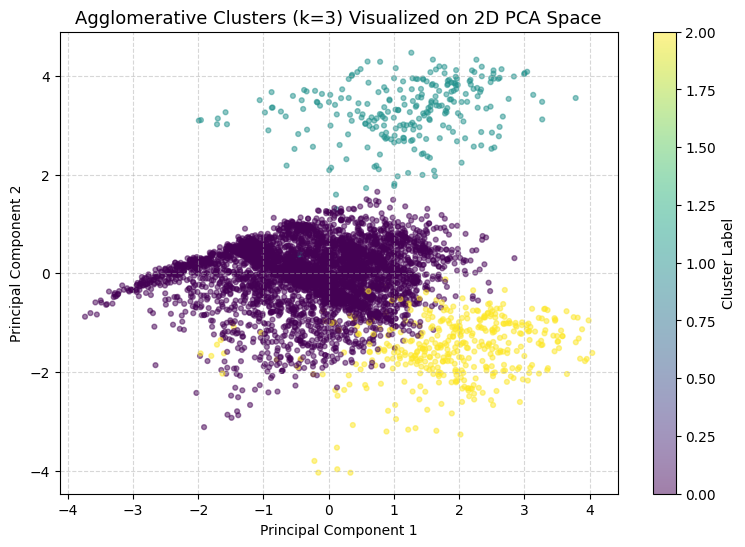

In [117]:
#Agglomeratve clustering polt
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:5000, 0], X_pca[:5000, 1], c=agg_labels, cmap='viridis', alpha=0.5, s=12)
plt.colorbar(scatter, label='Cluster Label')
plt.title('Agglomerative Clusters (k=3) Visualized on 2D PCA Space', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Task 4: Interpretation & Profiling

1. Average Numerical Traits per Cluster


,age,education-num,hours-per-week,capital-gain,capital-loss
KMeans_Cluster,,,,,
0,37.87,9.94,38.93,0.03,0.0
1,41.58,10.98,41.49,0.00,1803.8
2,43.75,11.07,41.73,7589.36,0.0



2. Dominant Categorical Traits per Cluster


,education,marital-status,workclass,occupation,sex
KMeans_Cluster,,,,,
0,HS-grad,Married-civ-spouse,Private,Prof-specialty,Male
1,HS-grad,Married-civ-spouse,Private,Prof-specialty,Male
2,HS-grad,Married-civ-spouse,Private,Prof-specialty,Male



3. Income Distribution (% within cluster)


income,<=50K,>50K
KMeans_Cluster,,
0,81.06,18.94
1,49.85,50.15
2,38.14,61.86


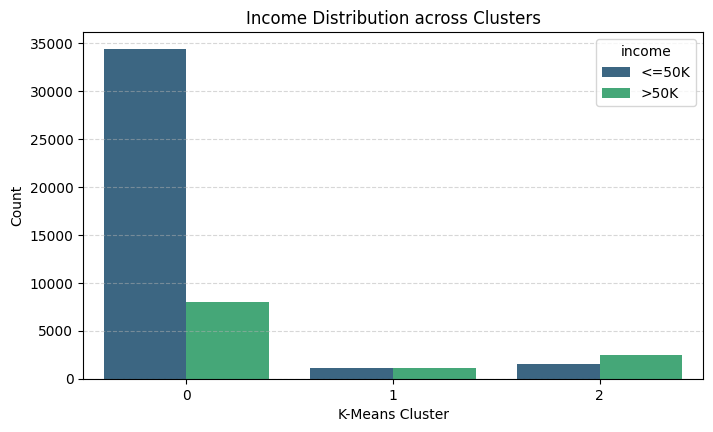

In [118]:
df['income'] = df['income'].str.rstrip('.')
print("1. Average Numerical Traits per Cluster")
num_profile = df.groupby('KMeans_Cluster')[['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']].mean().round(2)
display(num_profile)
print("\n2. Dominant Categorical Traits per Cluster")
cat_profile = df.groupby('KMeans_Cluster')[['education', 'marital-status', 'workclass', 'occupation', 'sex']].agg(lambda x: x.mode()[0])
display(cat_profile)
print("\n3. Income Distribution (% within cluster)")
income_dist = pd.crosstab(df['KMeans_Cluster'], df['income'], normalize='index') * 100
display(income_dist.round(2))

plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='KMeans_Cluster', hue='income', palette='viridis')
plt.title('Income Distribution across Clusters')
plt.xlabel('K-Means Cluster')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Cluster Key Findings

* **Cluster 0 — Entry-Level / Younger Segment:**
  * **Characteristics:** Younger demographic (approx. 37.8 years), lower education (approx. 9.9 years / HS-Grad), and standard 38.9 work hours/week with zero capital gains or losses.
  * **Income Profile:** Primarily lower-income earners (approx. 81% earning <=50K).

* **Cluster 1 — Mid-Career / Investment Loss Segment:**
  * **Characteristics:** Slightly older (approx. 41.6 years), higher education (approx. 11 years), working approx. 41.5 hours/week. Characterized by significant capital losses (average approx. $1,803).
  * **Income Profile:** Balanced split (approx. 50% earning >50K).

* **Cluster 2 — High-Earner / Executive Capital Gain Segment:**
  * **Characteristics:** Highest average age (approx. 43.8 years), highest education level (approx. 11.1 years), working approx. 41.7 hours/week, with substantial capital gains (average approx. $7,589).
  * **Income Profile:** Highest proportion of high earners (approx. 62% earning >50K).